# EEGNet — BCI Competition IV 2a

Experiments:
1. **LOSO** over combined data T+E — 2 classes
2. **LOSO** over combined data T+E — 4 classes
3. **Channel ablation** (11ch vs 22ch) with the best config
3. **Within-subject T→E** (standard) with the best config

## 0 · Imports

In [1]:
import sys
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = os.path.abspath('..')
sys.path.append(PROJECT_ROOT)

from src.load_data_BCICIV import load_all_subjects, load_combined
from src.train_EEGNet import run_loso, run_within_subject_T_to_E

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

/home/alumno/Desktop/datos/a/Biosignal-ML-Analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 1 · Routes

In [2]:
DATA_DIR  = '../datasets/BCICIV_2a_gdf'
LABEL_DIR = '../datasets/BCICIV_2a_gdf/true_labels'

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

## 2 · Experiment grid

In [3]:
EXPERIMENT_GRID = [
    {'name': 'base',               'transforms': ['base'],         'augment': False, 'lr': 3e-4, 'epochs': 300, 'patience': 40},
    {'name': 'laplacian',          'transforms': ['laplacian'],    'augment': False, 'lr': 3e-4, 'epochs': 300, 'patience': 40},
    {'name': 'laplacian_aug',      'transforms': ['laplacian'],    'augment': True, 'lr': 3e-4, 'epochs': 300, 'patience': 40},
    {'name': 'multiband',          'transforms': ['multiband'],    'augment': False, 'lr': 3e-4, 'epochs': 300, 'patience': 40},
    {'name': 'multiband_lap',      'transforms': ['multiband', 'laplacian'], 'augment': False, 'lr': 3e-4, 'epochs': 300, 'patience': 40},
    {'name': 'multiband_lap_aug',  'transforms': ['multiband', 'laplacian'], 'augment': True, 'lr': 3e-4, 'epochs': 300, 'patience': 40}
]

print(f'{len(EXPERIMENT_GRID)} configurations × 2 (classes) = {len(EXPERIMENT_GRID)*2} runs LOSO')

6 configurations × 2 (classes) = 12 runs LOSO


## 3 · Load combined data T+E (for LOSO)

In [4]:
print('Loading data 2 classes...')
X2, y2, subj2 = load_combined(DATA_DIR, LABEL_DIR, n_classes=2)

print('Loading data 4 classes...')
X4, y4, subj4 = load_combined(DATA_DIR, LABEL_DIR, n_classes=4)

Loading data 2 classes...


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading: A01T.gdf | left_hand: 71 | right_hand: 72


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading: A02T.gdf | left_hand: 72 | right_hand: 72


...

Loading (eval): A07E.gdf | left_hand: 72 | right_hand: 72 | feet: 71 | tongue: 72


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval): A08E.gdf | left_hand: 72 | right_hand: 72 | feet: 71 | tongue: 72


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval): A09E.gdf | left_hand: 72 | right_hand: 72 | feet: 71 | tongue: 72
Combined T+E | Shape: (5166, 11, 1000) | ~574 trials/subject


## 4 · LOSO Experiments  — 2 classes

In [5]:
results_loso_2 = []

for cfg in EXPERIMENT_GRID:
    run_name = f"EEGNet_2cls_{cfg['name']}"
    print(f'\n=== LOSO 2 classes | {run_name} ===')

    if 'multiband' in cfg['transforms']:
        X_mb, y_mb, subj_mb = load_combined(
            DATA_DIR, LABEL_DIR, n_classes=2, use_multiband=True
        )
        res = run_loso(X_mb, y_mb, subj_mb, cfg, num_classes=2, run_name=run_name)
    else:
        res = run_loso(X2,   y2,   subj2,   cfg, num_classes=2, run_name=run_name)

    results_loso_2.append({
        'config':    cfg['name'],
        'classes':   2,
        'mean_acc':  res['mean'],
        'std_acc':   res['std'],
        **res['per_subject']
    })

df_loso_2 = pd.DataFrame(results_loso_2).sort_values('mean_acc', ascending=False)
print('\n--- Results for LOSO 2 classes ---')
df_loso_2[['config','mean_acc','std_acc']]


=== LOSO 2 classes | EEGNet_2cls_base ===


Early stop epoch 80 | best val_acc: 0.7543


  Fold 01 | Subject A01 | Train 1956 | Val 346 | Best Val 0.7543 | Test 0.8397


Early stop epoch 52 | best val_acc: 0.7977


  Fold 02 | Subject A02 | Train 1955 | Val 346 | Best Val 0.7977 | Test 0.5625


...

Early stop epoch 54 | best val_acc: 0.6936


  Fold 08 | Subject A08 | Train 1955 | Val 346 | Best Val 0.6936 | Test 0.7153


Early stop epoch 79 | best val_acc: 0.7428


  Fold 09 | Subject A09 | Train 1955 | Val 346 | Best Val 0.7428 | Test 0.6007
  → Mean: 0.7034 ± 0.0861


--- Results for LOSO 2 classes ---


,config,mean_acc,std_acc
2,laplacian_aug,0.717288,0.100672
1,laplacian,0.714246,0.099021
0,base,0.709202,0.109242
4,multiband_lap,0.703788,0.089370
5,multiband_lap_aug,0.703426,0.086058
3,multiband,0.699931,0.091247


## 5 · LOSO Experiments — 4 classes

In [6]:
results_loso_4 = []

for cfg in EXPERIMENT_GRID:
    run_name = f"EEGNet_4cls_{cfg['name']}"
    print(f'\n=== LOSO 4 classes | {run_name} ===')

    if 'multiband' in cfg['transforms']:
        X_mb, y_mb, subj_mb = load_combined(
            DATA_DIR, LABEL_DIR, n_classes=4, use_multiband=True
        )
        res = run_loso(X_mb, y_mb, subj_mb, cfg, num_classes=4, run_name=run_name)
    else:
        res = run_loso(X4,   y4,   subj4,   cfg, num_classes=4, run_name=run_name)

    results_loso_4.append({
        'config':   cfg['name'],
        'classes':  4,
        'mean_acc': res['mean'],
        'std_acc':  res['std'],
        **res['per_subject']
    })

df_loso_4 = pd.DataFrame(results_loso_4).sort_values('mean_acc', ascending=False)
print('\n--- Results for LOSO 4 classes ---')
df_loso_4[['config','mean_acc','std_acc']]


=== LOSO 4 classes | EEGNet_4cls_base ===


Early stop epoch 126 | best val_acc: 0.4528


  Fold 01 | Subject A01 | Train 3903 | Val 689 | Best Val 0.4528 | Test 0.5627


Early stop epoch 82 | best val_acc: 0.4819


  Fold 02 | Subject A02 | Train 3903 | Val 689 | Best Val 0.4819 | Test 0.3293


...

Early stop epoch 56 | best val_acc: 0.4557


  Fold 08 | Subject A08 | Train 3903 | Val 689 | Best Val 0.4557 | Test 0.4111


Early stop epoch 71 | best val_acc: 0.4369


  Fold 09 | Subject A09 | Train 3903 | Val 689 | Best Val 0.4369 | Test 0.3850
  → Mean: 0.3978 ± 0.0759


--- Results for LOSO 4 classes ---


,config,mean_acc,std_acc
0,base,0.410569,0.078948
3,multiband,0.410376,0.071502
2,laplacian_aug,0.406698,0.076068
4,multiband_lap,0.405730,0.068394
1,laplacian,0.399342,0.080441
5,multiband_lap_aug,0.397793,0.075921


## 6 · LOSO summary  and best model selection

In [7]:
df_all_loso = pd.concat([df_loso_2, df_loso_4], ignore_index=True)

display_cols = ['config', 'classes', 'mean_acc', 'std_acc']

print('===== Global ranking LOSO =====')
print(df_all_loso[display_cols].sort_values('mean_acc', ascending=False).to_string(index=False))

best_2cls = df_loso_2.iloc[0]
best_4cls = df_loso_4.iloc[0]

print(f'\nBest for 2 classes → {best_2cls["config"]}  ({best_2cls["mean_acc"]:.4f} ± {best_2cls["std_acc"]:.4f})')
print(f'Best for 4 classes → {best_4cls["config"]}  ({best_4cls["mean_acc"]:.4f} ± {best_4cls["std_acc"]:.4f})')

best_cfg_2 = next(c for c in EXPERIMENT_GRID if c['name'] == best_2cls['config'])
best_cfg_4 = next(c for c in EXPERIMENT_GRID if c['name'] == best_4cls['config'])

===== Global ranking LOSO =====
           config  classes  mean_acc  std_acc
    laplacian_aug        2  0.717288 0.100672
        laplacian        2  0.714246 0.099021
             base        2  0.709202 0.109242
    multiband_lap        2  0.703788 0.089370
multiband_lap_aug        2  0.703426 0.086058
        multiband        2  0.699931 0.091247
             base        4  0.410569 0.078948
        multiband        4  0.410376 0.071502
    laplacian_aug        4  0.406698 0.076068
    multiband_lap        4  0.405730 0.068394
        laplacian        4  0.399342 0.080441
multiband_lap_aug        4  0.397793 0.075921

Best for 2 classes → laplacian_aug  (0.7173 ± 0.1007)
Best for 4 classes → base  (0.4106 ± 0.0789)


## 7 · Channel ablation

In [8]:
print('\nLoading 22ch data for channel ablation...')

if 'multiband' in best_cfg_2['transforms']:
    X2_22, y2_22, subj2_22 = load_combined(
        DATA_DIR, LABEL_DIR, n_classes=2, use_multiband=True, channels_to_use='all'
    )
else:
    X2_22, y2_22, subj2_22 = load_combined(
        DATA_DIR, LABEL_DIR, n_classes=2, channels_to_use='all'
    )

if 'multiband' in best_cfg_4['transforms']:
    X4_22, y4_22, subj4_22 = load_combined(
        DATA_DIR, LABEL_DIR, n_classes=4, use_multiband=True, channels_to_use='all'
    )
else:
    X4_22, y4_22, subj4_22 = load_combined(
        DATA_DIR, LABEL_DIR, n_classes=4, channels_to_use='all'
    )


Loading 22ch data for channel ablation...


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading: A01T.gdf | left_hand: 71 | right_hand: 72


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading: A02T.gdf | left_hand: 72 | right_hand: 72


...

Loading (eval): A07E.gdf | left_hand: 72 | right_hand: 72 | feet: 71 | tongue: 72


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval): A08E.gdf | left_hand: 72 | right_hand: 72 | feet: 71 | tongue: 72


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval): A09E.gdf | left_hand: 72 | right_hand: 72 | feet: 71 | tongue: 72
Combined T+E | Shape: (5166, 22, 1000) | ~574 trials/subject


In [9]:

results_ch_ablation = []

for n_cls, best_cfg, (X_11, y_11, s_11), (X_22, y_22, s_22) in [
    (2, best_cfg_2, (X2,    y2,    subj2),    (X2_22, y2_22, subj2_22)),
    (4, best_cfg_4, (X4,    y4,    subj4),    (X4_22, y4_22, subj4_22)),
]:
    for label, X_use, y_use, s_use in [
        ('11ch', X_11, y_11, s_11),
        ('22ch', X_22, y_22, s_22),
    ]:
        run_name = f"EEGNet_{n_cls}cls_{best_cfg['name']}_{label}"
        print(f'\n=== Ablation | {n_cls} classes | {best_cfg["name"]} | {label} ===')

        if label == '11ch':
            existing = df_loso_2 if n_cls == 2 else df_loso_4
            row = existing[existing['config'] == best_cfg['name']].iloc[0]
            results_ch_ablation.append({
                'channels': label, 'classes': n_cls,
                'mean_acc': row['mean_acc'], 'std_acc': row['std_acc'],
            })
            print(f'  (reusing LOSO results) → {row["mean_acc"]:.4f} ± {row["std_acc"]:.4f}')
            continue

        res = run_loso(X_use, y_use, s_use, best_cfg, num_classes=n_cls, run_name=run_name)
        results_ch_ablation.append({
            'channels': label, 'classes': n_cls,
            'mean_acc': res['mean'], 'std_acc': res['std'],
        })

df_ch_ablation = pd.DataFrame(results_ch_ablation)
print('\n--- Channel ablation (best config perclass) ---')
print(df_ch_ablation[['channels', 'classes', 'mean_acc', 'std_acc']]
      .sort_values(['classes', 'channels'])
      .to_string(index=False))


=== Ablation | 2 classes | laplacian_aug | 11ch ===
  (reusing LOSO results) → 0.7173 ± 0.1007

=== Ablation | 2 classes | laplacian_aug | 22ch ===


Early stop epoch 64 | best val_acc: 0.7428


  Fold 01 | Subject A01 | Train 1956 | Val 346 | Best Val 0.7428 | Test 0.8049


Early stop epoch 86 | best val_acc: 0.7977


  Fold 02 | Subject A02 | Train 1955 | Val 346 | Best Val 0.7977 | Test 0.5486


...

  Fold 07 | Subject A07 | Train 3903 | Val 689 | Best Val 0.4746 | Test 0.4547


Early stop epoch 72 | best val_acc: 0.4601


  Fold 08 | Subject A08 | Train 3903 | Val 689 | Best Val 0.4601 | Test 0.4251


Early stop epoch 118 | best val_acc: 0.5123


  Fold 09 | Subject A09 | Train 3903 | Val 689 | Best Val 0.5123 | Test 0.3972
  → Mean: 0.4154 ± 0.0798


--- Channel ablation (best config perclass) ---
channels  classes  mean_acc  std_acc
    11ch        2  0.717288 0.100672
    22ch        2  0.707697 0.095979
    11ch        4  0.410569 0.078948
    22ch        4  0.415408 0.079790


## 8 · Load data — T and E separately (for within-subject)

In [10]:
print('Loading T (train) y E (eval) separately...')

multiband_2 = 'multiband' in best_cfg_2['transforms'] 
multiband_4 = 'multiband' in best_cfg_4['transforms'] 

data_T_2 = load_all_subjects(DATA_DIR, stage='T', n_classes=2, use_multiband=multiband_2)
data_E_2 = load_all_subjects(DATA_DIR, stage='E', label_dir=LABEL_DIR, n_classes=2, use_multiband=multiband_2)

data_T_4 = load_all_subjects(DATA_DIR, stage='T', n_classes=4, use_multiband=multiband_4)
data_E_4 = load_all_subjects(DATA_DIR, stage='E', label_dir=LABEL_DIR, n_classes=4, use_multiband=multiband_4)

print(f'T 2cls: {data_T_2["X"].shape} | E 2cls: {data_E_2["X"].shape}')
print(f'T 4cls: {data_T_4["X"].shape} | E 4cls: {data_E_4["X"].shape}')

Loading T (train) y E (eval) separately...


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading: A01T.gdf | left_hand: 71 | right_hand: 72


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading: A02T.gdf | left_hand: 72 | right_hand: 72


...

Loading (eval): A07E.gdf | left_hand: 72 | right_hand: 72 | feet: 71 | tongue: 72


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval): A08E.gdf | left_hand: 72 | right_hand: 72 | feet: 71 | tongue: 72


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval): A09E.gdf | left_hand: 72 | right_hand: 72 | feet: 71 | tongue: 72
T 2cls: (1294, 11, 1000) | E 2cls: (1295, 11, 1000)
T 4cls: (2583, 11, 1000) | E 4cls: (2583, 11, 1000)


## 9 · Within-subject T→E with the best model

In [11]:
print(f'\n=== Within-subject T→E | 2 classes | config: {best_cfg_2["name"]} ===')

res_within_2 = run_within_subject_T_to_E(
    data_T_2['X'], data_T_2['y'], data_T_2['subject_ids'],
    data_E_2['X'], data_E_2['y'], data_E_2['subject_ids'],
    cfg=best_cfg_2, num_classes=2,
    run_name=f"EEGNet_within_2cls_{best_cfg_2['name']}"
)

print(f'\n=== Within-subject T→E | 4 classes | config: {best_cfg_4["name"]} ===')

res_within_4 = run_within_subject_T_to_E(
    data_T_4['X'], data_T_4['y'], data_T_4['subject_ids'],
    data_E_4['X'], data_E_4['y'], data_E_4['subject_ids'],
    cfg=best_cfg_4, num_classes=4,
    run_name=f"EEGNet_within_4cls_{best_cfg_4['name']}"
)


=== Within-subject T→E | 2 classes | config: laplacian_aug ===


Early stop epoch 43 | best val_acc: 0.6207


  Subject A01 | Train 114 | Val 29 | Best Val 0.6207 | Eval(E) 0.4931


Early stop epoch 54 | best val_acc: 0.6552


  Subject A02 | Train 115 | Val 29 | Best Val 0.6552 | Eval(E) 0.5139


...

  Subject A07 | Train 229 | Val 58 | Best Val 0.5862 | Eval(E) 0.6098


Early stop epoch 65 | best val_acc: 0.3276


  Subject A08 | Train 229 | Val 58 | Best Val 0.3276 | Eval(E) 0.2753


Early stop epoch 73 | best val_acc: 0.4310


  Subject A09 | Train 229 | Val 58 | Best Val 0.4310 | Eval(E) 0.4111
  → Mean: 0.3782 ± 0.1002



## 10 · Final comparison

In [12]:
summary = pd.DataFrame([
    {
        'Experiment':  'LOSO',
        'Classes':       2,
        'Config':       best_2cls['config'],
        'Mean Acc':     f"{best_2cls['mean_acc']:.4f}",
        'Std Acc':      f"{best_2cls['std_acc']:.4f}",
    },
    {
        'Experiment':  'LOSO',
        'Classes':       4,
        'Config':       best_4cls['config'],
        'Mean Acc':     f"{best_4cls['mean_acc']:.4f}",
        'Std Acc':      f"{best_4cls['std_acc']:.4f}",
    },
    {
        'Experiment':  'Within T→E',
        'Classes':       2,
        'Config':       best_cfg_2['name'],
        'Mean Acc':     f"{res_within_2['mean']:.4f}",
        'Std Acc':      f"{res_within_2['std']:.4f}",
    },
    {
        'Experiment':  'Within T→E',
        'Classes':       4,
        'Config':       best_cfg_4['name'],
        'Mean Acc':     f"{res_within_4['mean']:.4f}",
        'Std Acc':      f"{res_within_4['std']:.4f}",
    },
    *[
        {
            'Experiment': 'LOSO ch-ablation',
            'Classes':    row['classes'],
            'Config':     best_cfg_2['name'] if row['classes'] == 2 else best_cfg_4['name'],
            'Channels':   row['channels'],
            'Mean Acc':   f"{row['mean_acc']:.4f}",
            'Std Acc':    f"{row['std_acc']:.4f}",
        }
        for _, row in df_ch_ablation[df_ch_ablation['channels'] == '22ch'].iterrows()
    ],
])

print('\n========== FINAL RESULTS ==========')
print(summary.to_string(index=False))

df_within = pd.DataFrame({
    'Subject':      list(res_within_2['per_subject'].keys()),
    'Acc 2cls (E)': list(res_within_2['per_subject'].values()),
    'Acc 4cls (E)': list(res_within_4['per_subject'].values()),
})
df_within.loc['mean'] = ['mean',
                         res_within_2['mean'],
                         res_within_4['mean']]
print('\n--- Within-subject detail per subject ---')
print(df_within.to_string(index=False))


========== FINAL RESULTS ==========
      Experiment  Classes        Config Mean Acc Std Acc Channels
            LOSO        2 laplacian_aug   0.7173  0.1007      NaN
            LOSO        4          base   0.4106  0.0789      NaN
      Within T→E        2 laplacian_aug   0.5884  0.1192      NaN
      Within T→E        4          base   0.3782  0.1002      NaN
LOSO ch-ablation        2 laplacian_aug   0.7077  0.0960     22ch
LOSO ch-ablation        4          base   0.4154  0.0798     22ch

--- Within-subject detail per subject ---
Subject  Acc 2cls (E)  Acc 4cls (E)
    A01      0.493056      0.459930
    A02      0.513889      0.285714
    A03      0.854167      0.379791
    A04      0.538462      0.320557
    A05      0.680556      0.362369
    A06      0.493056      0.299652
    A07      0.465278      0.609756
    A08      0.583333      0.275261
    A09      0.673611      0.411150
   mean      0.588378      0.378242


## 11 · Visualization

/home/alumno/Desktop/datos/a/Biosignal-ML-Analysis/src/visualization_eeg.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha='right')


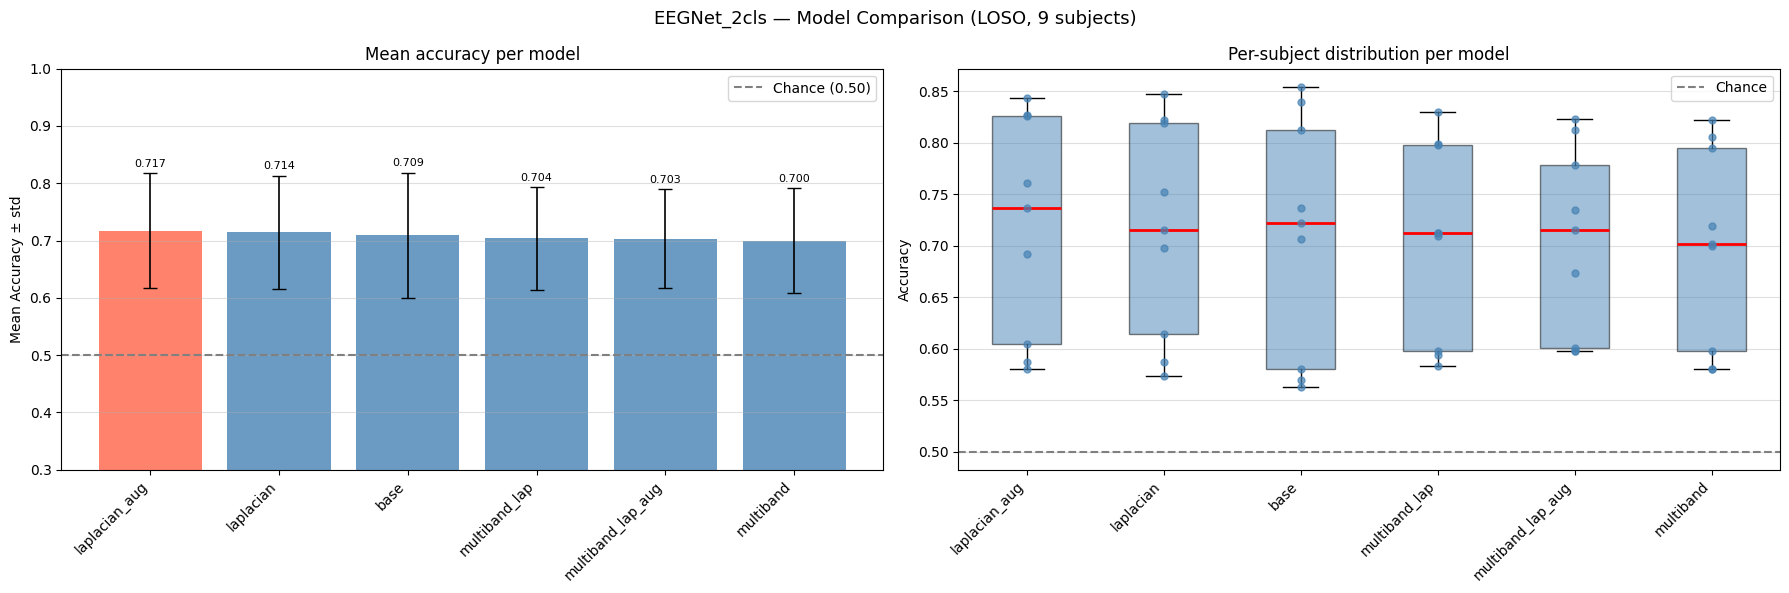

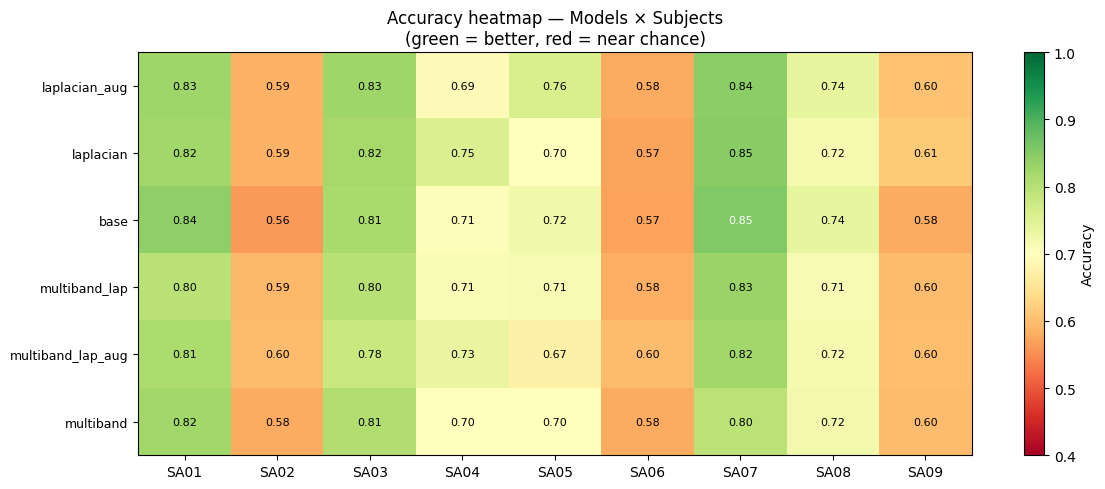

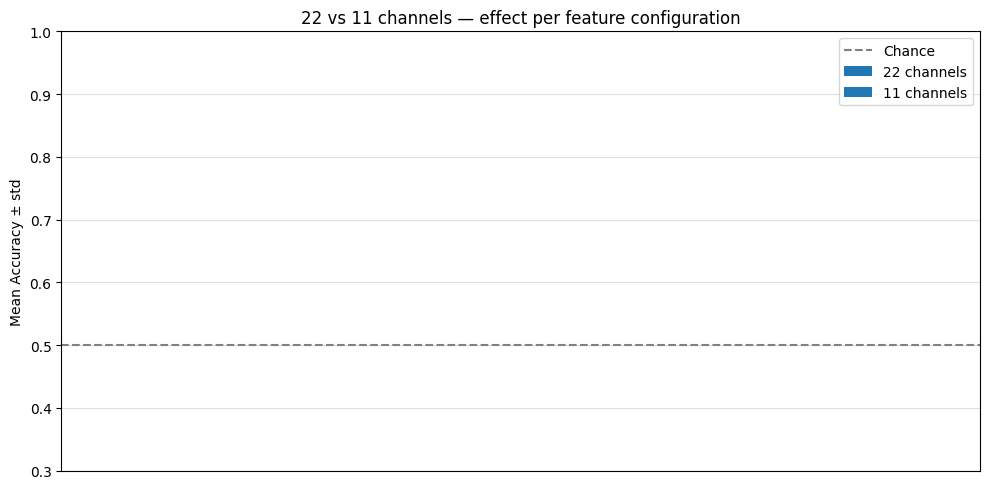

In [13]:
from src.visualization_eeg import visualize_deep

meta_cols = ['config', 'classes', 'mean_acc', 'std_acc']
subj_cols_2 = [c for c in df_loso_2.columns if c not in meta_cols]

models_2 = {
    'name':        list(df_loso_2['config']),
    'accuracies':  df_loso_2[subj_cols_2].values.tolist(),
}

visualize_deep(models_2, subjects=subj_cols_2, model_label='EEGNet_2cls',
               save_dir='../figures', CHANCE=0.5)

/home/alumno/Desktop/datos/a/Biosignal-ML-Analysis/src/visualization_eeg.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha='right')


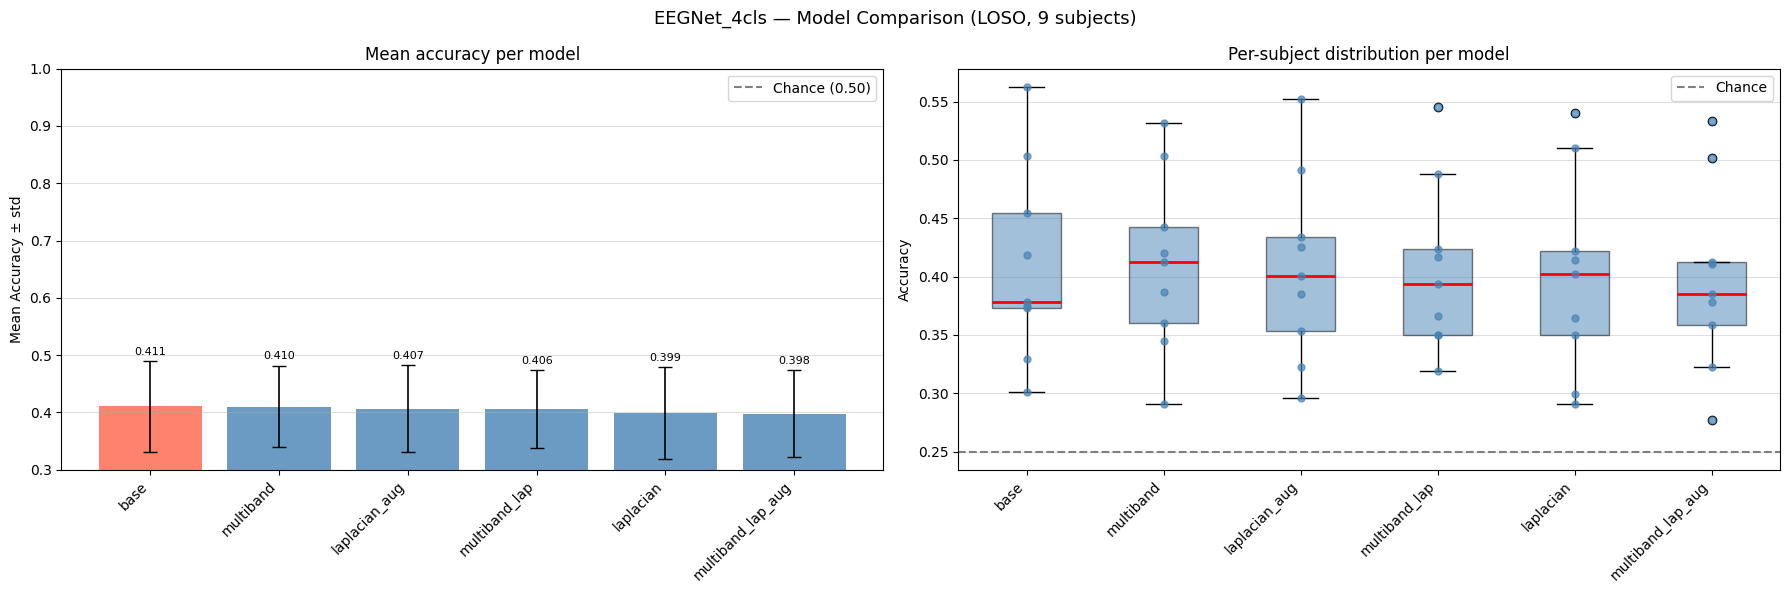

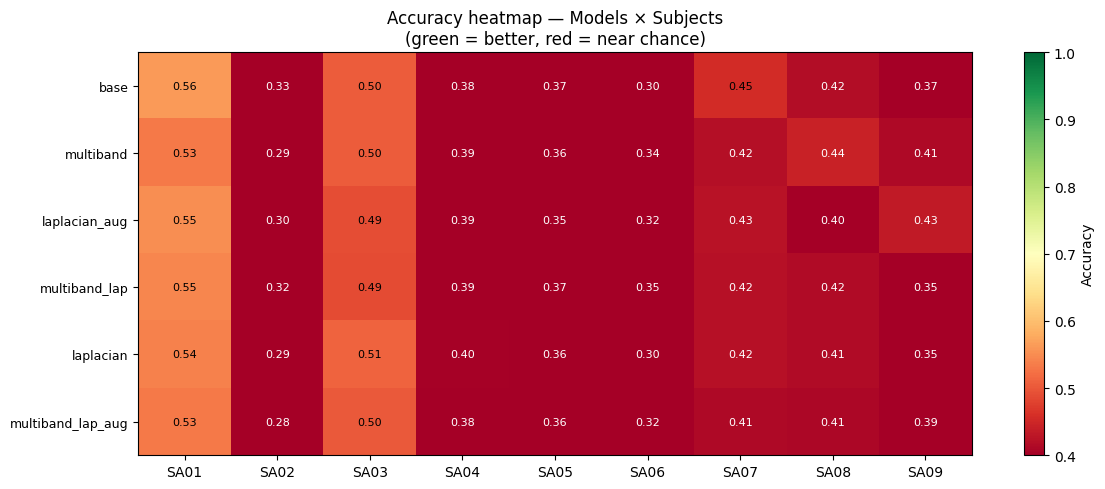

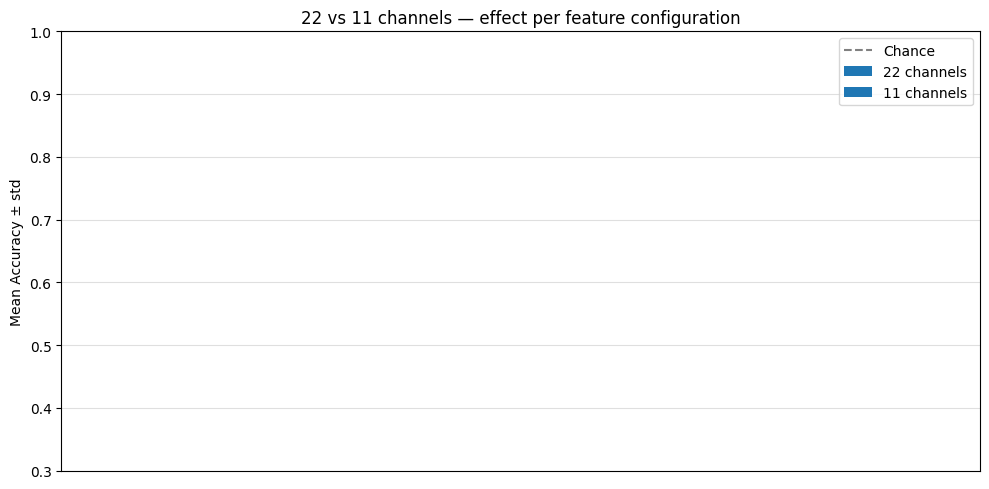

In [14]:
subj_cols_4 = [c for c in df_loso_4.columns if c not in meta_cols]

models_4 = {
    'name':        list(df_loso_4['config']),
    'accuracies':  df_loso_4[subj_cols_4].values.tolist(),
}

visualize_deep(models_4, subjects=subj_cols_4, model_label='EEGNet_4cls',
               save_dir='../figures', CHANCE=0.25)

2 clases | laplacian_aug | 11ch: 0.7173
4 clases | base | 11ch: 0.4106


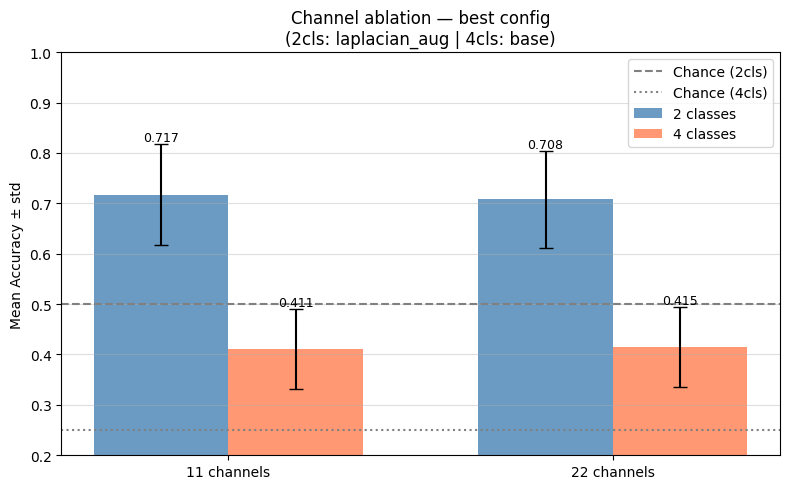

In [15]:
rows_abl = []
for _, row in df_ch_ablation.iterrows():
    cfg_name = best_cfg_2['name'] if row['classes'] == 2 else best_cfg_4['name']
    rows_abl.append({
        'name':    f"{cfg_name}_{row['channels']}",   
        'classes': row['classes'],
        'mean_acc': row['mean_acc'],
        'std_acc':  row['std_acc'],
    })
df_abl_viz = pd.DataFrame(rows_abl)


for cls, df_src in [(2, df_loso_2), (4, df_loso_4)]:
    best_name = best_cfg_2['name'] if cls == 2 else best_cfg_4['name']
    subj_cols = [c for c in df_src.columns if c not in meta_cols]
    row_11 = df_src[df_src['config'] == best_name].iloc[0]
    print(f'{cls} clases | {best_name} | 11ch: {row_11["mean_acc"]:.4f}')


fig, ax = plt.subplots(figsize=(8, 5))
abl_2 = df_ch_ablation[df_ch_ablation['classes'] == 2].set_index('channels')
abl_4 = df_ch_ablation[df_ch_ablation['classes'] == 4].set_index('channels')

x = np.arange(2)
w = 0.35
b1 = ax.bar(x - w/2, abl_2.loc[['11ch','22ch'], 'mean_acc'],
            w, yerr=abl_2.loc[['11ch','22ch'], 'std_acc'],
            capsize=5, label='2 classes', color='steelblue', alpha=0.8)
b2 = ax.bar(x + w/2, abl_4.loc[['11ch','22ch'], 'mean_acc'],
            w, yerr=abl_4.loc[['11ch','22ch'], 'std_acc'],
            capsize=5, label='4 classes', color='coral', alpha=0.8)
ax.bar_label(b1, fmt='%.3f', fontsize=9)
ax.bar_label(b2, fmt='%.3f', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(['11 channels', '22 channels'])
ax.axhline(0.5, color='gray', linestyle='--', label='Chance (2cls)')
ax.axhline(0.25, color='gray', linestyle=':', label='Chance (4cls)')
ax.set_ylim(0.2, 1.0); ax.set_ylabel('Mean Accuracy ± std')
ax.set_title(f'Channel ablation — best config\n(2cls: {best_cfg_2["name"]} | 4cls: {best_cfg_4["name"]})')
ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('../figures/EEGNet_channel_ablation.png', dpi=150, bbox_inches='tight')
plt.show()